## AD Channel 


Applied Bell state, AD-U0,AD-U1,RTN-U0,RTN-U!
 Ansatz and training 
Ansatz - Realamplitude 
Optimizer - COBYLA

this model trains all 5 classes 

In [1]:
import numpy as np
%matplotlib inline
import plotly.express as px
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns

import matplotlib.pyplot as plt


from IPython.display import clear_output
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap
from qiskit_algorithms.optimizers import COBYLA, L_BFGS_B
from qiskit_algorithms.utils import algorithm_globals

from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier, VQC
from qiskit_machine_learning.algorithms.regressors import NeuralNetworkRegressor, VQR
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.circuit.library import QNNCircuit
from qiskit.circuit.library import UnitaryGate
from scipy.linalg import sqrtm, eig
from qiskit.circuit import ParameterVector

from qiskit.quantum_info import *
from qiskit import *
import numpy as np
import math
from qiskit.quantum_info import concurrence, state_fidelity, average_gate_fidelity, process_fidelity, Statevector
import matplotlib.pyplot as plt
from qiskit.circuit.library import UnitaryGate
from scipy.linalg import sqrtm, eig
from sympy import symbols, sqrt
from qiskit.quantum_info.operators import Operator, Pauli, SparsePauliOp
import sympy

from qiskit.circuit.library import RealAmplitudes,EfficientSU2,NLocal,TwoLocal
from qiskit.circuit.library import NLocal, CXGate, CRZGate, RXGate
from qiskit.circuit import Parameter
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import SparsePauliOp

algorithm_globals.random_seed = 42

In [2]:
data = pd.read_csv('all-class.csv')

# data['true_label']=data['concurrence'].apply(lambda x: 0 if x == 0 else 1)

In [2]:
url = 'https://raw.githubusercontent.com/Thirumalai-97/QuantumStateClassification_UsingQNN/refs/heads/main/ThreeQubit/Dataset/threeQubitData.csv'
data = pd.read_csv(url)

In [3]:
data = data.dropna()

In [4]:
data

,theta,gamma_1,time_1,gamma_2,time_2,gamma_3,time_3,entanglement_class
0,1.570796,0.00,20.0,0.90,20.0,0.00,20.0,AB-C
1,1.570796,0.00,20.1,0.90,20.1,0.00,20.1,AB-C
2,1.570796,0.00,20.2,0.90,20.2,0.00,20.2,AB-C
3,1.570796,0.00,20.3,0.90,20.3,0.00,20.3,AB-C
4,1.570796,0.00,20.4,0.90,20.4,0.00,20.4,AB-C
...,...,...,...,...,...,...,...,...
4795,0.000000,0.11,99.5,0.22,99.5,0.33,99.5,SP
4796,0.000000,0.11,99.6,0.22,99.6,0.33,99.6,SP
4797,0.000000,0.11,99.7,0.22,99.7,0.33,99.7,SP
4798,0.000000,0.11,99.8,0.22,99.8,0.33,99.8,SP


In [5]:
class_mapping = {'GE': 0,'AB-C':1 ,'AC-B':2 , 'BC-A':3 , 'SP': 4}
data['entanglement_class'] = data['entanglement_class'].map(class_mapping)

In [6]:
data_features = data.iloc[:, 0:7]
data_labels = data.iloc[:,7]
data_features

,theta,gamma_1,time_1,gamma_2,time_2,gamma_3,time_3
0,1.570796,0.00,20.0,0.90,20.0,0.00,20.0
1,1.570796,0.00,20.1,0.90,20.1,0.00,20.1
2,1.570796,0.00,20.2,0.90,20.2,0.00,20.2
3,1.570796,0.00,20.3,0.90,20.3,0.00,20.3
4,1.570796,0.00,20.4,0.90,20.4,0.00,20.4
...,...,...,...,...,...,...,...
4795,0.000000,0.11,99.5,0.22,99.5,0.33,99.5
4796,0.000000,0.11,99.6,0.22,99.6,0.33,99.6
4797,0.000000,0.11,99.7,0.22,99.7,0.33,99.7
4798,0.000000,0.11,99.8,0.22,99.8,0.33,99.8


In [7]:
data_labels

0       1
1       1
2       1
3       1
4       1
       ..
4795    4
4796    4
4797    4
4798    4
4799    4
Name: entanglement_class, Length: 4800, dtype: int64

In [8]:
X = data_features
y = data_labels

In [9]:
import plotly.express as px
plt.figure(figsize=(10, 6))
fig = px.scatter_3d(data, x='time_1', y='theta', z='gamma_2', color='entanglement_class')
fig.show()


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

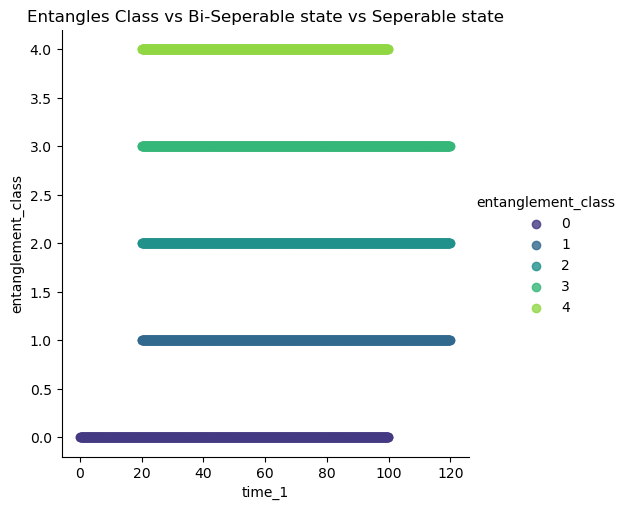

In [10]:
plt.figure(figsize=(10, 10))
sns.lmplot(x='time_1', y='entanglement_class', hue='entanglement_class', palette='viridis', data=data)
plt.title('Entangles Class vs Bi-Seperable state vs Seperable state')
plt.xlabel('time_1')
plt.ylabel('entanglement_class')
#plt.legend(title='Label')
plt.show()

In [11]:
num_qubits=3
num_qubits

3

In [12]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter, Gate


class AD0(Gate):
    def __init__(self, x,y, label=None):
        super().__init__('AD0', 2, [x,y], label=label)
        
        
    
    def _define(self):
        qc = QuantumCircuit(2)
        qc.unitary(self.unitary_mat_0()[0], [0, 1])
       
        self.definition = qc

    
    def kraus_list(self,gamma,t):
        nf= np.exp(-gamma*t)
        k1=[[1,0],[0,np.sqrt(nf)]]
        k2=[[0,np.sqrt(1-nf)],[0,0]]
        return k1,k2
    


    def unitary_mat_0(self):
        gamma = self.params[0]
        t = self.params[1]
        #print(f'gamma_1-{gamma}, time_1-{t}\n')
        k_list=self.kraus_list(gamma,t)
        k0=np.array(k_list[0])
        k1=np.array(k_list[1])
        D0=sqrtm(np.identity(2)-np.matmul(k0.T.conjugate(),k0))
        D0dag=sqrtm(np.identity(2)-np.matmul(k0,k0.T.conjugate()))
        D1=sqrtm(np.identity(2)-np.matmul(k1.T.conjugate(),k1))
        D1dag=sqrtm(np.identity(2)-np.matmul(k1,k1.T.conjugate()))

        z=np.array([[1,0],[0,-1]])
        x=np.array([[0,1],[1,0]])
        y=np.array([[0,-1j],[1j,0]])

        u0= np.kron((x-1j*y)/2,D0)+ np.kron((x+1j*y)/2,D0dag)+np.kron((np.identity(2)+z)/2,k0)-np.kron((np.identity(2)-z)/2,k0.T.conjugate())
        u1= np.kron((x-1j*y)/2,D1)+ np.kron((x+1j*y)/2,D1dag)+np.kron((np.identity(2)+z)/2,k1)-np.kron((np.identity(2)-z)/2,k1.T.conjugate())


        return u0,u1


class AD1(Gate):
    def __init__(self, x,y, label=None):
        super().__init__('AD1', 2, [x,y], label=label)
        
        
    
    def _define(self):
        qc = QuantumCircuit(2)
       
        qc.unitary(self.unitary_mat_0()[1], [0, 1])
        self.definition = qc

    
    def kraus_list(self,gamma,t):
        nf= np.exp(-gamma*t)
        k1=[[1,0],[0,np.sqrt(nf)]]
        k2=[[0,np.sqrt(1-nf)],[0,0]]
        return k1,k2
    


    def unitary_mat_0(self):
        gamma = self.params[0]
        t = self.params[1]
        #print(f'gamma_2-{gamma}, time_2-{t}\n')
        k_list=self.kraus_list(gamma,t)
        k0=np.array(k_list[0])
        k1=np.array(k_list[1])
        D0=sqrtm(np.identity(2)-np.matmul(k0.T.conjugate(),k0))
        D0dag=sqrtm(np.identity(2)-np.matmul(k0,k0.T.conjugate()))
        D1=sqrtm(np.identity(2)-np.matmul(k1.T.conjugate(),k1))
        D1dag=sqrtm(np.identity(2)-np.matmul(k1,k1.T.conjugate()))

        z=np.array([[1,0],[0,-1]])
        x=np.array([[0,1],[1,0]])
        y=np.array([[0,-1j],[1j,0]])

        u0= np.kron((x-1j*y)/2,D0)+ np.kron((x+1j*y)/2,D0dag)+np.kron((np.identity(2)+z)/2,k0)-np.kron((np.identity(2)-z)/2,k0.T.conjugate())
        u1= np.kron((x-1j*y)/2,D1)+ np.kron((x+1j*y)/2,D1dag)+np.kron((np.identity(2)+z)/2,k1)-np.kron((np.identity(2)-z)/2,k1.T.conjugate())


        return u0,u1

class AD2(Gate):
    def __init__(self, x,y, label=None):
        super().__init__('AD2', 2, [x,y], label=label)
        
        
    
    def _define(self):
        qc = QuantumCircuit(2)
        qc.unitary(self.unitary_mat_0()[0], [0, 1])
       
        self.definition = qc

    
    def kraus_list(self,gamma,t):
        nf= np.exp(-gamma*t)
        k1=[[1,0],[0,np.sqrt(nf)]]
        k2=[[0,np.sqrt(1-nf)],[0,0]]
        return k1,k2
    


    def unitary_mat_0(self):
        gamma = self.params[0]
        t = self.params[1]
        #print(f'gamma_3-{gamma}, time_3-{t}\n')
        k_list=self.kraus_list(gamma,t)
        k0=np.array(k_list[0])
        k1=np.array(k_list[1])
        D0=sqrtm(np.identity(2)-np.matmul(k0.T.conjugate(),k0))
        D0dag=sqrtm(np.identity(2)-np.matmul(k0,k0.T.conjugate()))
        D1=sqrtm(np.identity(2)-np.matmul(k1.T.conjugate(),k1))
        D1dag=sqrtm(np.identity(2)-np.matmul(k1,k1.T.conjugate()))

        z=np.array([[1,0],[0,-1]])
        x=np.array([[0,1],[1,0]])
        y=np.array([[0,-1j],[1j,0]])

        u0= np.kron((x-1j*y)/2,D0)+ np.kron((x+1j*y)/2,D0dag)+np.kron((np.identity(2)+z)/2,k0)-np.kron((np.identity(2)-z)/2,k0.T.conjugate())
        u1= np.kron((x-1j*y)/2,D1)+ np.kron((x+1j*y)/2,D1dag)+np.kron((np.identity(2)+z)/2,k1)-np.kron((np.identity(2)-z)/2,k1.T.conjugate())


        return u0,u1

        
class RTN0(Gate):
    def __init__(self, x,y, label=None):
        super().__init__('RTN0', 2, [x,y], label=label)
        
        
    
    def _define(self):
        qc = QuantumCircuit(2)
        qc.unitary(self.unitary_mat_rtn()[0], [0, 1])
       
        self.definition = qc

    
    def kraus_list_rtn(self,gamma,t):
        a=0.5
        gamma = gamma
        hf=np.sqrt(((2*a)/gamma**2)-1)
        nf=np.exp(-gamma*t)*((np.cos(hf*(gamma*t))+(np.sin(hf*(gamma*t))/hf)))
        k1=[[np.sqrt((1+nf)/2),0],[0,np.sqrt((1+nf)/2)]]
        k2=[[np.sqrt((1-nf)/2),0],[0,-np.sqrt((1-nf)/2)]]
        

       
          

        return k1,k2


    def unitary_mat_rtn(self):
        gamma = self.params[0]
        t = self.params[1]
        #print(f'gamma_1-{gamma}, time_1-{t}\n')
        k_list=self.kraus_list_rtn(gamma,t)
        k0=np.array(k_list[0])
        k1=np.array(k_list[1])
        D0=sqrtm(np.identity(2)-np.matmul(k0.T.conjugate(),k0))
        D0dag=sqrtm(np.identity(2)-np.matmul(k0,k0.T.conjugate()))
        D1=sqrtm(np.identity(2)-np.matmul(k1.T.conjugate(),k1))
        D1dag=sqrtm(np.identity(2)-np.matmul(k1,k1.T.conjugate()))

        z=np.array([[1,0],[0,-1]])
        x=np.array([[0,1],[1,0]])
        y=np.array([[0,-1j],[1j,0]])
        
        u0= np.kron((x-1j*y)/2,D0)+ np.kron((x+1j*y)/2,D0dag)+np.kron((np.identity(2)+z)/2,k0)-np.kron((np.identity(2)-z)/2,k0.T.conjugate())
        u1= np.kron((x-1j*y)/2,D1)+ np.kron((x+1j*y)/2,D1dag)+np.kron((np.identity(2)+z)/2,k1)-np.kron((np.identity(2)-z)/2,k1.T.conjugate())


        return u0,u1





class RTN1(Gate):
    def __init__(self, x,y, label=None):
        super().__init__('RTN1', 2, [x,y], label=label)
 
    def _define(self):
        qc = QuantumCircuit(2)
        
        qc.unitary(self.unitary_mat_rtn()[1], [0, 1])
        self.definition = qc

    def kraus_list_rtn(self,gamma,t):
        a=0.51
        gamma = gamma
        hf=np.sqrt(((2*a)/gamma**2)-1)
        nf=np.exp(-gamma*t)*((np.cos(hf*(gamma*t))+(np.sin(hf*(gamma*t))/hf)))
        k1=[[np.sqrt((1+nf)/2),0],[0,np.sqrt((1+nf)/2)]]
        k2=[[np.sqrt((1-nf)/2),0],[0,-np.sqrt((1-nf)/2)]]
     
        return k1,k2


    def unitary_mat_rtn(self):
        gamma = self.params[0]
        t = self.params[1]
        #print(f'gamma_2-{gamma}, time_2-{t}\n')
        k_list=self.kraus_list_rtn(gamma,t)
       
        k0=np.array(k_list[0])
        k1=np.array(k_list[1])
        D0=sqrtm(np.identity(2)-np.matmul(k0.T.conjugate(),k0))
        D0dag=sqrtm(np.identity(2)-np.matmul(k0,k0.T.conjugate()))
        D1=sqrtm(np.identity(2)-np.matmul(k1.T.conjugate(),k1))
        D1dag=sqrtm(np.identity(2)-np.matmul(k1,k1.T.conjugate()))

        z=np.array([[1,0],[0,-1]])
        x=np.array([[0,1],[1,0]])
        y=np.array([[0,-1j],[1j,0]])
        
        u0= np.kron((x-1j*y)/2,D0)+ np.kron((x+1j*y)/2,D0dag)+np.kron((np.identity(2)+z)/2,k0)-np.kron((np.identity(2)-z)/2,k0.T.conjugate())
        u1= np.kron((x-1j*y)/2,D1)+ np.kron((x+1j*y)/2,D1dag)+np.kron((np.identity(2)+z)/2,k1)-np.kron((np.identity(2)-z)/2,k1.T.conjugate())


        return u0,u1


class RTN2(Gate):
    def __init__(self, x,y, label=None):
        super().__init__('RTN2', 2, [x,y], label=label)
 
    def _define(self):
        qc = QuantumCircuit(2)
        
        qc.unitary(self.unitary_mat_rtn()[1], [0, 1])
        self.definition = qc

    def kraus_list_rtn(self,gamma,t):
        a=0.51
        gamma = gamma
        hf=np.sqrt(((2*a)/gamma**2)-1)
        nf=np.exp(-gamma*t)*((np.cos(hf*(gamma*t))+(np.sin(hf*(gamma*t))/hf)))
        k1=[[np.sqrt((1+nf)/2),0],[0,np.sqrt((1+nf)/2)]]
        k2=[[np.sqrt((1-nf)/2),0],[0,-np.sqrt((1-nf)/2)]]
     
        return k1,k2


    def unitary_mat_rtn(self):
        gamma = self.params[0]
        t = self.params[1]
        #print(f'gamma_3-{gamma}, time_3-{t}\n')
        k_list=self.kraus_list_rtn(gamma,t)
       
        k0=np.array(k_list[0])
        k1=np.array(k_list[1])
        D0=sqrtm(np.identity(2)-np.matmul(k0.T.conjugate(),k0))
        D0dag=sqrtm(np.identity(2)-np.matmul(k0,k0.T.conjugate()))
        D1=sqrtm(np.identity(2)-np.matmul(k1.T.conjugate(),k1))
        D1dag=sqrtm(np.identity(2)-np.matmul(k1,k1.T.conjugate()))

        z=np.array([[1,0],[0,-1]])
        x=np.array([[0,1],[1,0]])
        y=np.array([[0,-1j],[1j,0]])
        
        u0= np.kron((x-1j*y)/2,D0)+ np.kron((x+1j*y)/2,D0dag)+np.kron((np.identity(2)+z)/2,k0)-np.kron((np.identity(2)-z)/2,k0.T.conjugate())
        u1= np.kron((x-1j*y)/2,D1)+ np.kron((x+1j*y)/2,D1dag)+np.kron((np.identity(2)+z)/2,k1)-np.kron((np.identity(2)-z)/2,k1.T.conjugate())


        return u0,u1




num_qubits = 2
x = ParameterVector('x', length=7)

feature_map=QuantumCircuit(3)
feature_map.ry(x[0],0)
feature_map.cx(0,1)
feature_map.cx(1,2)





feature_map.append(AD0(x[1],x[2]),[0,1])
feature_map.append(AD0(x[3],x[4]),[1,2])
feature_map.append(AD0(x[5],x[6]),[2,0])

#feature_map.append(RTN1(x[3],x[4]),[0,1])
#feature_map.append(RTN0(x[1],x[2]),[1,2])
#feature_map.append(RTN2(x[5],x[6]),[0,2])



feature_map.draw()



┌──────────┐          ┌─────────────────┐                   »
q_0: ┤ Ry(x[0]) ├──■───────┤0                ├───────────────────»
     └──────────┘┌─┴─┐     │  Ad0(x[1],x[2]) │┌─────────────────┐»
q_1: ────────────┤ X ├──■──┤1                ├┤0                ├»
                 └───┘┌─┴─┐└─────────────────┘│  Ad0(x[3],x[4]) │»
q_2: ─────────────────┤ X ├───────────────────┤1                ├»
                      └───┘                   └─────────────────┘»
«     ┌─────────────────┐
«q_0: ┤1                ├
«     │                 │
«q_1: ┤  Ad0(x[5],x[6]) ├
«     │                 │
«q_2: ┤0                ├
«     └─────────────────┘

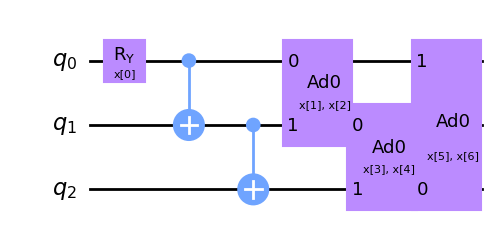

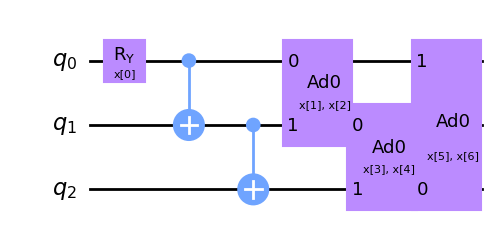

In [13]:
feature_map.draw(output='mpl',style="clifford")

In [14]:


# ansatz = RealAmplitudes(num_qubits=3, reps=1)
# ansatz.decompose().draw(output="mpl", style="clifford", fold=50)





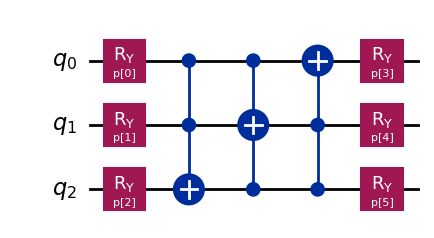

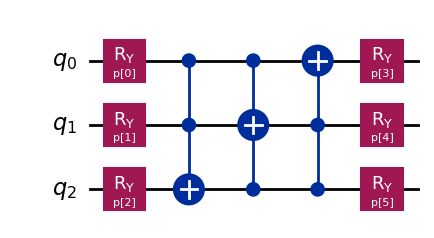

In [15]:
myansatz = QuantumCircuit(3)
p = ParameterVector('p', length=6)

myansatz.ry(p[0],0)
myansatz.ry(p[1],1)
myansatz.ry(p[2],2)


myansatz.ccx(0,1,2)
myansatz.ccx(0,2,1)
myansatz.ccx(2,1,0)

myansatz.ry(p[3],0)
myansatz.ry(p[4],1)
myansatz.ry(p[5],2)

myansatz.draw('mpl')

In [16]:
model=QuantumCircuit(3)
model.append(feature_map,[0,1,2])
model.append(myansatz,[0,1,2])

# model.decompose().decompose().draw("mpl", style="clifford")

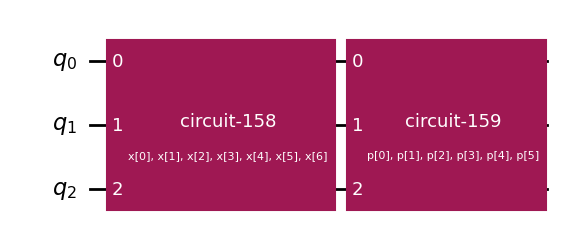

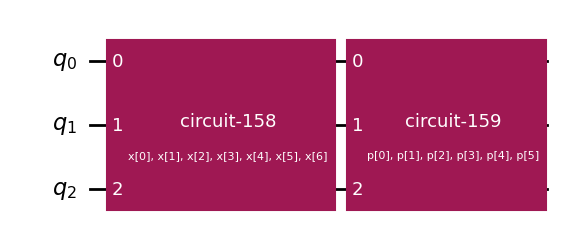

In [17]:
model.draw('mpl')

In [18]:
myansatz.measure_all()

In [19]:
from qiskit.quantum_info import random_unitary
from qiskit import QuantumCircuit
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import DensityMatrix
from qiskit_algorithms.state_fidelities import base_state_fidelity
from qiskit.visualization import plot_state_qsphere
import matplotlib.pyplot as plt
from scipy import integrate
from qiskit_algorithms.gradients import ParamShiftSamplerGradient

In [20]:
grad = []
fidelity = []
variances = []
def calculate_gradient(train_features, variational):
#         """Calculate KL divergence for the dataset."""
#     train_features = train_features.to_numpy()
    variational = [variational]
#     print(model.num_parameters)
        
    sampler = Sampler()
    gradient = ParamShiftSamplerGradient(sampler)

    print(variational)
    pss_grad_result = gradient.run(myansatz, variational).result().gradients
    pss = list(pss_grad_result[-1][-1].values())
    grad.append(pss)
#     print("State sampler gradient computed with parameter shift", pss_grad_result)
    variances.append(np.var(pss))
    return variances

In [21]:
grad = []
fidelity = []
surface_values = []
def calculate_estimator(variational_all):
    n_qubits = 3
#         """Calculate KL divergence for the dataset."""
#     train_features = train_features.to_numpy()
    for i in range(len(variational_all)):
        variational = [variational_all[i]]
    #     print(model.num_parameters)
        ansatz = myansatz
        estimator = Estimator()
        op = SparsePauliOp(['I' * (n_qubits - 2) + 'ZZ'])
        pss_grad_result = estimator.run(ansatz, op, variational).result().values[0]
        print(pss_grad_result)
        global surface_values
        surface_values.append(pss_grad_result)

In [22]:
from qiskit_algorithms.optimizers import COBYLA,AQGD,SPSA,ADAM

optimizer = COBYLA(maxiter=50)
from qiskit.primitives import Sampler

sampler = Sampler()
from matplotlib import pyplot as plt
from IPython.display import clear_output

objective_func_vals = []
plt.rcParams["figure.figsize"] = (6, 6)


gradient = []
weights_all = []
objective_func_vals = []
def callback_graph(weights, obj_func_eval):
    clear_output(wait=True)
    global objective_func_vals
    objective_func_vals.append(obj_func_eval)
    global weights_all
    weights_all.append(weights)
    print("weights",weights)
    kl_t = calculate_gradient(train_features,weights)
    global gradient
    gradient.append(kl_t)
#     accuracy_t = calculate_accuracy(weights)
#     accuracy.appned(accuracy_t)
#     plt.title("Objective function value against iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Loss function value")
    plt.plot(range(len(objective_func_vals)), objective_func_vals,label='cost')
#     ax2.plot(range(len(kl)), kl_t, label='kl')
#     plt.plot(range(len(objective_func_vals)), accuracy,label='accuracy')
    plt.savefig("3qubit_loss_iteration_t.png",dpi=300,bbox_inches='tight')
    plt.show()

In [23]:
from sklearn.model_selection import train_test_split
from qiskit_algorithms.utils import algorithm_globals

algorithm_globals.random_seed = 42

train_features, val_features, train_labels, val_labels = train_test_split(
    data_features, data_labels, test_size=0.2, random_state=42
)


In [24]:
train_labels = np.array(train_labels).reshape(-1, 1)


In [25]:
from sklearn.metrics import log_loss
num_epochs = 1
train_losses = []
val_losses = []

def compute_loss(predictions, labels):
    return log_loss(labels, predictions)


weights [0.77395605 0.43887844 0.85859792 0.69736803 0.09417735 0.97562235]
[array([0.77395605, 0.43887844, 0.85859792, 0.69736803, 0.09417735,
       0.97562235])]


OSError: [Errno 30] Read-only file system: '3qubit_loss_iteration_t.png'

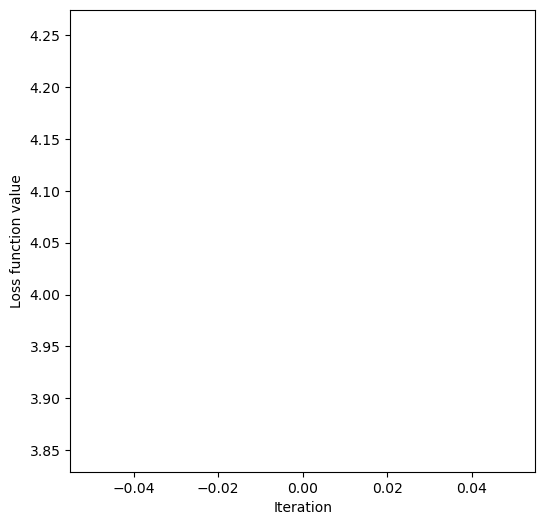

In [26]:
from qiskit_machine_learning.algorithms.classifiers import VQC

vqc = VQC(
    sampler=sampler,
    feature_map=feature_map,
    ansatz=myansatz,
    optimizer=optimizer,
    callback=callback_graph,
)

# Training loop over epochs
# for epoch in range(num_epochs):

# Fit the model
start = time.time()
vqc.fit(train_features, train_labels)
elapsed = time.time() - start

# Predict on training and validation data
train_predictions = vqc.predict(train_features)
val_predictions = vqc.predict(val_features)
obj_pro_2qcsv = pd.DataFrame(objective_func_vals)
obj_pro_2qcsv.to_csv("objective_func_vals_proposed_3q.csv")
    # # Compute losses
    # train_loss = compute_loss(train_predictions, train_labels)
    # val_loss = compute_loss(val_predictions, val_labels)

    # #Store losses
    # train_losses.append(train_loss)
    # val_losses.append(val_loss)

    # Print epoch details
    # print(f"Epoch {epoch+1}/{num_epochs} - Training Loss: {train_loss:.4f} - Validation Loss: {val_loss:.4f} - Time: {elapsed:.2f}s")




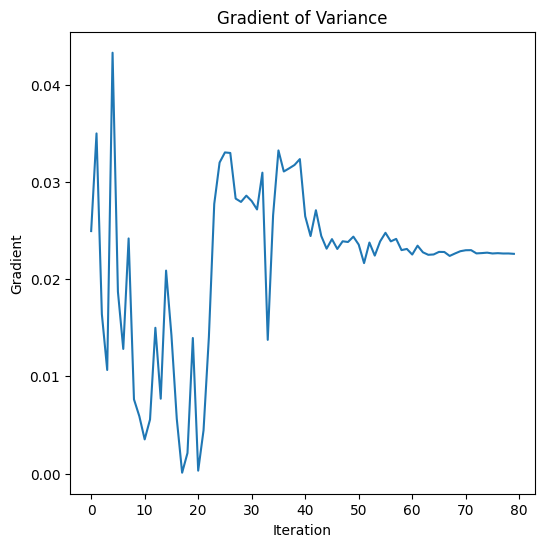

In [ ]:
plt.title("Gradient of Variance")
plt.xlabel("Iteration")
plt.ylabel("Gradient")
x = np.arange(len(gradient[-1]))
plt.plot(x, gradient[-1],label='cost')

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss,classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score,accuracy_score
from qiskit import QuantumCircuit
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap
from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit.primitives import Sampler
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [28]:
print(classification_report(val_labels,val_predictions))

NameError: name 'val_predictions' is not defined

In [38]:
accuracy_score(val_labels,val_predictions)

0.9854166666666667

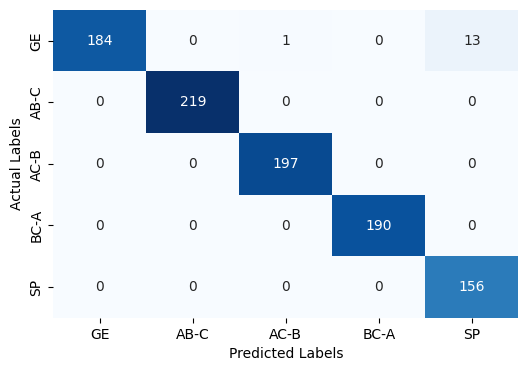

In [41]:
# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(val_labels,val_predictions), annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['GE', 'AB-C','AC-B','BC-A','SP'],
            yticklabels=['GE', 'AB-C','AC-B','BC-A','SP'])

# Add labels and title
plt.ylabel('Actual Labels')
plt.xlabel('Predicted Labels')
# plt.title('Confusion Matrix')

# Show the plot
plt.savefig('three_qubit_classification_proposed.png',dpi=300,bbox_inches='tight')
plt.show()

In [48]:
df = pd.DataFrame(weights_all)
df.to_csv("weights_all_grad.csv")

In [28]:
# for i in range(num_epochs):
#     print(f'Epoch {i+1}/{num_epochs} - Training Loss: {train_loss:.4f} - Validation Loss: {val_loss:.4f} - Time: {elapsed:.2f}s" ')

In [29]:
vqc.score(train_features, train_labels)

0.9919270833333333

In [35]:
train_score_q4 = vqc.score(train_features, train_labels)
val_score_q4 = vqc.score(val_features, val_labels)

print(f"Training dataset: {train_score_q4:.2f}")
print(f"Validation dataset:     {val_score_q4:.2f}")

Training dataset: 0.99
Validation dataset:     0.99


In [36]:
prediction = vqc.predict(val_features)

In [37]:
# # Plot the losses
# plt.figure(figsize=(6, 6))
# plt.plot(range(num_epochs), train_losses, label='Training Loss')
# plt.plot(range(num_epochs), val_losses, label='Validation Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.title('Training and Validation Loss Over Epochs')
# plt.legend()
# plt.show()

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score,accuracy_score
from qiskit import QuantumCircuit
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap
from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit.primitives import Sampler
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn import metrics




In [39]:
y_true = val_labels
y_pred = vqc.predict(val_features)

In [40]:
def binary_cross_entropy_loss(y_true, y_pred):
    epsilon = 1e-15  # small value to avoid log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


loss = binary_cross_entropy_loss(y_true, y_pred)

print("Binary Cross-Entropy Loss:", loss)

Binary Cross-Entropy Loss: -37.094065466774424


In [41]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("Mean Squared Error:", mse)
print("R-squared Score:", r2)


Mean Squared Error: 0.22083333333333333
R-squared Score: 0.8829827665215259


In [42]:
accuracy_score(y_true, y_pred)

0.9854166666666667

In [43]:
val_predictions = vqc.predict(val_features)
#val_predictions_proba = interpret_probabilities(val_predictions)

In [44]:
confusion_matrix = confusion_matrix(y_true, y_pred)
print('Confusion Matrix:')
print(confusion_matrix)


Confusion Matrix:
[[184   0   1   0  13]
 [  0 219   0   0   0]
 [  0   0 197   0   0]
 [  0   0   0 190   0]
 [  0   0   0   0 156]]


In [45]:
FP = confusion_matrix.sum(axis=0) - np.diag(confusion_matrix)  
FN = confusion_matrix.sum(axis=1) - np.diag(confusion_matrix)
TP = np.diag(confusion_matrix)
TN = confusion_matrix.sum() - (FP + FN + TP)

# Sensitivity, hit rate, recall, or true positive rate
TPR = TP/(TP+FN)
# Specificity or true negative rate
TNR = TN/(TN+FP) 
# Precision or positive predictive value
PPV = TP/(TP+FP)
# Negative predictive value
NPV = TN/(TN+FN)
# Fall out or false positive rate
FPR = FP/(FP+TN)
# False negative rate
FNR = FN/(TP+FN)
# False discovery rate
FDR = FP/(TP+FP)

# Overall accuracy
ACC = (TP+TN)/(TP+FP+FN+TN)

In [46]:
Recall = TPR
Precision =PPV
f1_score = 2*((Precision*Recall)/(Precision+Recall))

In [47]:
print(f'False Positive - {FP} \nFalse negative - {FN},\nTrue positive - {TP}, \nTrue negative - {TN} ')
print(f'\nTrue positive rate - {TPR}, \nTrue Negative rate - {TNR}, \nPrecision - {PPV}')
print(f'Accuracy - {ACC}')

print(f'Recall - {TPR}')
print(f'F1 Score - {f1_score}')

False Positive - [ 0  0  1  0 13] 
False negative - [14  0  0  0  0],
True positive - [184 219 197 190 156], 
True negative - [762 741 762 770 791] 

True positive rate - [0.92929293 1.         1.         1.         1.        ], 
True Negative rate - [1.         1.         0.99868938 1.         0.98383085], 
Precision - [1.         1.         0.99494949 1.         0.92307692]
Accuracy - [0.98541667 1.         0.99895833 1.         0.98645833]
Recall - [0.92929293 1.         1.         1.         1.        ]
F1 Score - [0.96335079 1.         0.99746835 1.         0.96      ]


In [48]:
print(f'fpr - {FPR},\ntpr - {TPR}')

fpr - [0.         0.         0.00131062 0.         0.01616915],
tpr - [0.92929293 1.         1.         1.         1.        ]


In [49]:
fpr, tpr, thresholds = metrics.roc_curve(y_true, y_pred, pos_label=2)
print(f'fpr - {fpr},\ntpr - {tpr}, \nthresholds - {thresholds}')

fpr - [0.         0.2214941  0.47051114 0.47182176 0.75884666 1.        ],
tpr - [0. 0. 0. 1. 1. 1.], 
thresholds - [inf  4.  3.  2.  1.  0.]


In [50]:
roc_auc = metrics.auc(fpr, tpr)
plt.text(-35, -70, "AUC: %.3f" % roc_auc, ha="right")
print("\n Area under the ROC curve : %f" % roc_auc)
plt.show()



 Area under the ROC curve : 0.528834


In [51]:
# fpr, tpr, _ = roc_curve(val_labels, val_predictions_proba)
# roc_auc = roc_auc_score(val_labels, val_predictions_proba)
# print(f'ROC AUC: {roc_auc:.4f}')


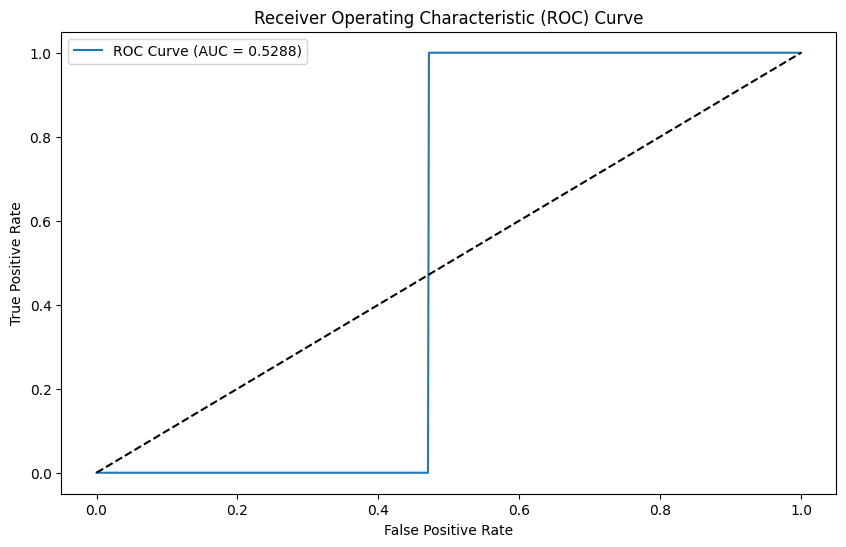

In [52]:
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
#plt.text(-35, -70, "AUC: %.3f" % roc_auc, ha="right")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [53]:
print(feature_map.depth(),myansatz.depth(),model.depth())

6 5 2


In [54]:
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
backend = FakeSherbrooke() 


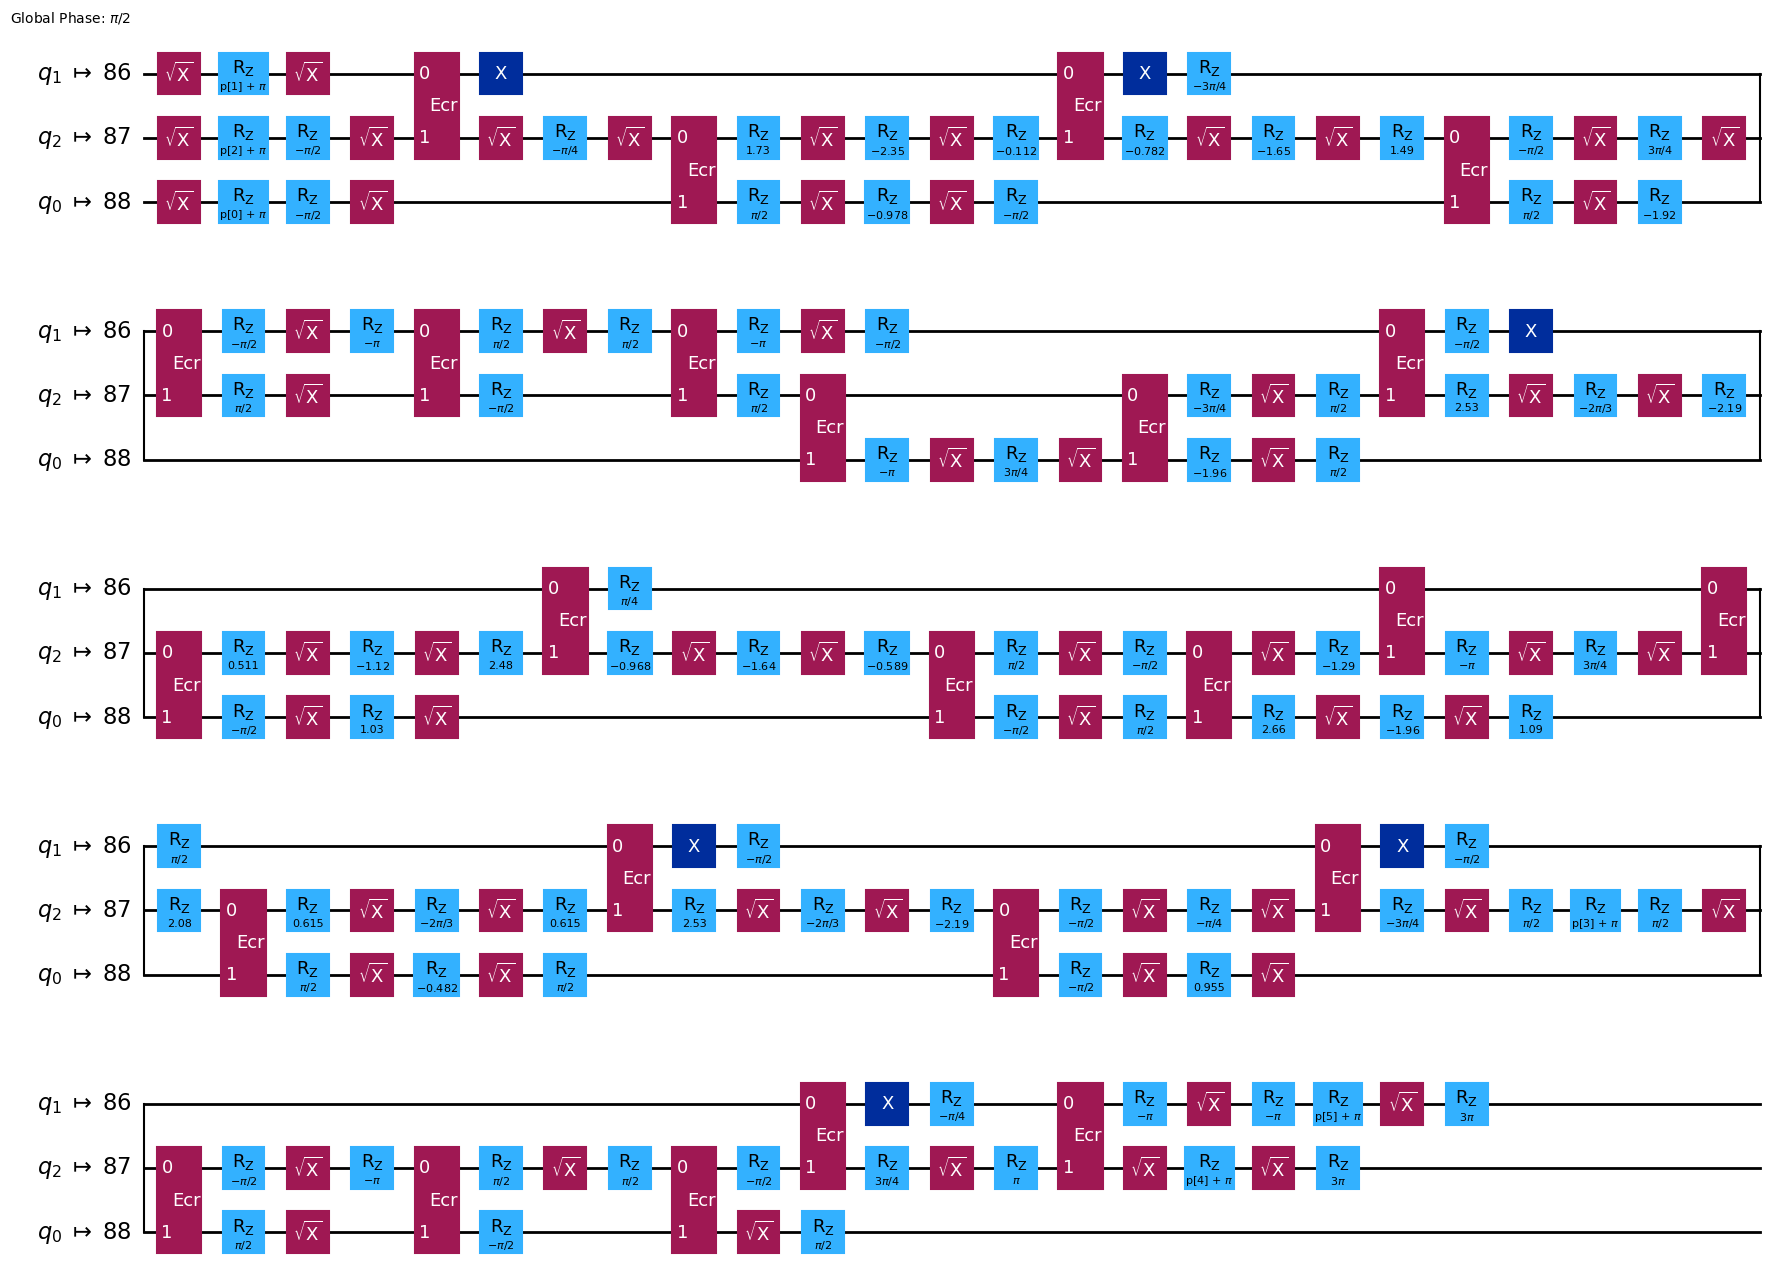

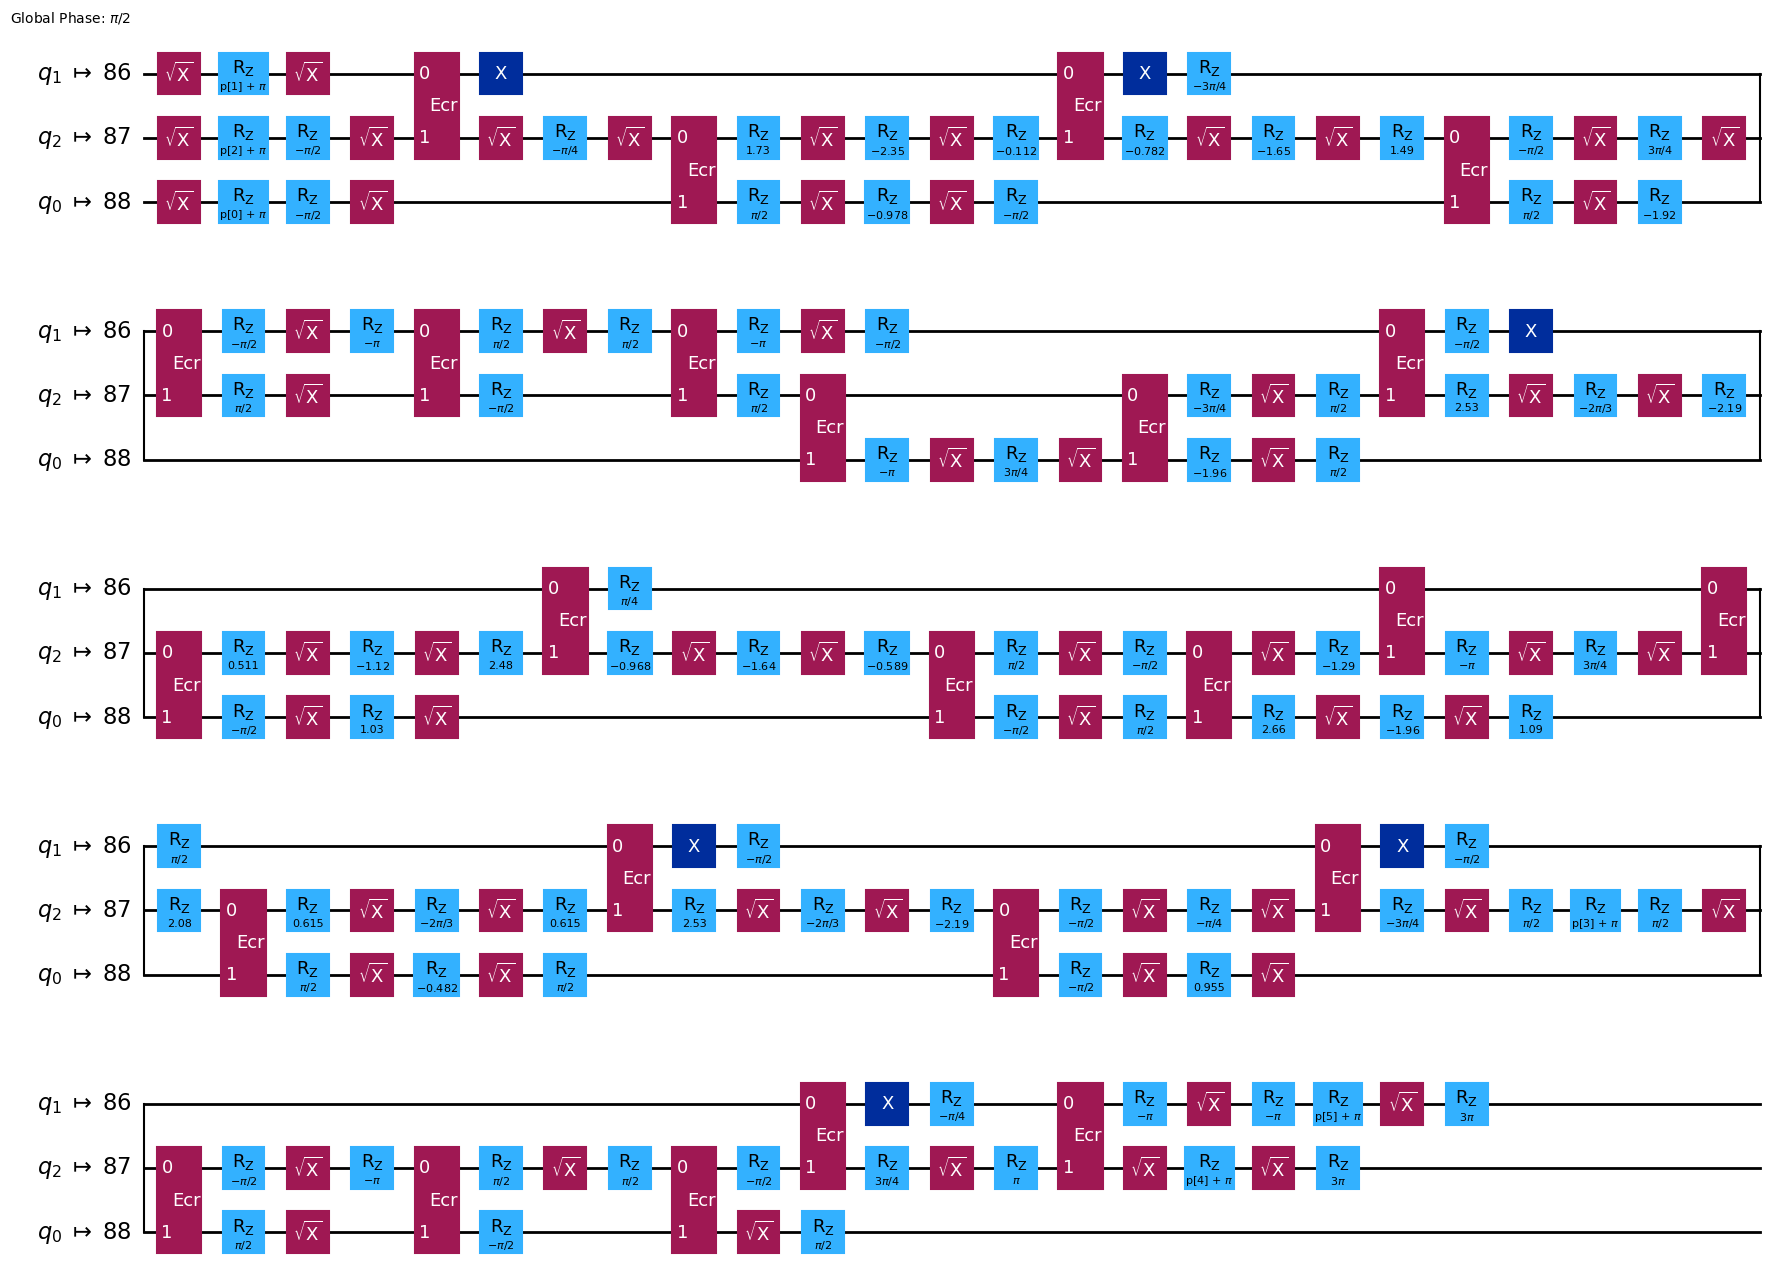

In [151]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

circuit_isa = pm.run(myansatz)
circuit_isa.draw(output="mpl", idle_wires=False, style="iqp")